# Dev33: Apply 057 SVM Model to 028 Crop Regions

**Goal**: Use the trained SVM from dev20 (trained on 057) and apply it to 028 crop regions (inverse of dev30).

**Workflow**:
1. Load saved SVM model from dev20 (057-trained, 3 classes)
2. Load and preprocess 028 transect (same preprocessing as dev20)
3. Classify the 4 crop regions from dev30
4. Visualize with plot_classification_as_image

**Key difference from dev30**:
- Dev30: 5-class SVM (sediment, rust, dark_bomb, dark_pit, halo) → classify 028 crops
- Dev33: 3-class SVM (training_dark, training_sediment, training_bombs) → classify 028 crops

## Setup and Import

In [1]:
import importlib
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

## Step 1: Load Trained SVM Model from 6_svm_general
**Note**: First run the save cell in dev20 to create the model file!

In [2]:
# Load the saved SVM model and preprocessing info
model_file = "./saved_data/svm_model_057_no_unknown.pkl"

if not os.path.exists(model_file):
    print("❌ ERROR: Model file not found!")
    print(f"   Looking for: {model_file}")
    print("\n📝 TO CREATE THE MODEL FILE:")
    print("   1. Open dev20 notebook")
    print("   2. Run all cells up to 'Train SVM'")
    print("   3. Run the '💾 SAVE SVM MODEL' cell")
    print("   4. Then come back here!")
    raise FileNotFoundError(f"Model file not found: {model_file}")
else:
    with open(model_file, "rb") as f:
        saved_model_data = pickle.load(f)

    # Extract model and parameters
    trained_model = saved_model_data["model"]
    class_names = saved_model_data["class_names"]
    label_encoder = saved_model_data["label_encoder"]
    preprocessing_params = saved_model_data["preprocessing"]
    best_params = saved_model_data["best_params"]

    print("✅ SVM model loaded successfully!")
    print(f"\n📊 Model Info:")
    print(f"   Classes: {class_names}")
    print(f"   Best C: {best_params['C']}")
    print(f"   Best gamma: {best_params['gamma']}")
    print(f"\n🔬 Preprocessing (will apply to 028):")
    print(f"   Wavelength range: {preprocessing_params['wavelength_range']} nm")
    print(f"   Smoothing: {preprocessing_params['smoothing_method']}")
    print(f"   Normalization: {preprocessing_params['normalization']}")

✅ SVM model loaded successfully!

📊 Model Info:
   Classes: ['training_dark', 'training_sediment', 'training_bombs']
   Best C: 0.1
   Best gamma: 0.1

🔬 Preprocessing (will apply to 028):
   Wavelength range: (490, 700) nm
   Smoothing: gaussian
   Normalization: None


## Step 2: Load 028 Transect (All 5 Files)

Same as dev30 - we load all 5 files to cover the crop regions.

In [3]:
# Load 028 transect
transect = load_transect(config.TRANSECT_028_OUTPUT)

transect.list_files()

# Select all 5 files from transect 028
cube = transect.select_files(
    [
        "rad_uhi_20241029_125028_1",
        "rad_uhi_20241029_125028_2",
        "rad_uhi_20241029_125028_3",
        "rad_uhi_20241029_125028_4",
        "rad_uhi_20241029_125028_5",
    ]
)
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_125028_1  | shape=(1329, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_125028_2  | shape=(2011, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_125028_3  | shape=(2282, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_125028_4  | shape=(2457, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_125028_5  | shape=(1948, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_125028_1
  rad_uhi_20241029_125028_1: Using GRIDDED format (T=1329, S=968)
   • rad_uhi_20241029_125028_2
  rad_uhi_20241029_125028_2: Using GRIDDED format (T=2011, S=968)
   • rad_uhi_20241029_125028_3
  rad_uhi_20241029_125028_3: Using GRIDDED format (T=2282, S=968)
   • rad_uhi_20241029_125028_4
  rad_uhi_20241029_125028_4: Using GRIDDED format (T=2457, S=968)
   • rad_uhi_20241029_125028_5
  rad_uhi_20241029_125028_5: Using GRIDDED format (T=1948, S=968)
✅ Combined shapes: X/Y/Z (10027, 968), RGB (

In [4]:
# Apply illumination correction
cube.apply_illumination_correction_v2()
print("✅ Illumination correction applied")

🔄 Using V2 algorithm (pandas rolling median, memory-efficient)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 5 files...
   rad_uhi_20241029_125028_1: window=500, strength=1.0
   rad_uhi_20241029_125028_2: window=500, strength=1.0
   rad_uhi_20241029_125028_3: window=500, strength=1.0
   rad_uhi_20241029_125028_4: window=500, strength=1.0
   rad_uhi_20241029_125028_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
✅ Illumination correction applied


## Step 3: Apply Same Preprocessing as dev30

In [5]:
# Apply spectral smoothing (same as dev20) - only if smoothing was used
if preprocessing_params["smoothing_method"] is not None:
    cube.apply_spectral_smoothing(
        method=preprocessing_params["smoothing_method"],
        gaussian_sigma=preprocessing_params["smoothing_sigma"],
    )
    print(
        f"✅ Spectral smoothing applied: {preprocessing_params['smoothing_method']} (σ={preprocessing_params['smoothing_sigma']})"
    )
else:
    print("✅ No spectral smoothing ")

💾 Found cached smoothing (gaussian, corrected data) - loading from disk (much faster!)
📂 Loading saved spectral smoothing (gaussian, corrected data) from 5 files...
   rad_uhi_20241029_125028_1: method=gaussian
   rad_uhi_20241029_125028_2: method=gaussian
   rad_uhi_20241029_125028_3: method=gaussian
   rad_uhi_20241029_125028_4: method=gaussian
   rad_uhi_20241029_125028_5: method=gaussian
✅ Loaded spectral smoothing from disk (saved computation time!)
✅ Spectral smoothing applied: gaussian (σ=5)


In [6]:
# Crop wavelengths (same as dev30)
wl_min, wl_max = preprocessing_params["wavelength_range"]
cube.apply_wavelength_filter(wavelength_range=(wl_min, wl_max))

print(f"✅ Wavelength cropping complete")
print(f"   Cropped shape: {cube.data_corrected.shape}")
print(f"   Wavelength range: {cube.wavelengths[0]:.1f} - {cube.wavelengths[-1]:.1f} nm")

🔪 WAVELENGTH FILTERING
📊 Original wavelengths: 210
🎯 Target range: 490-700 nm
✂️  Filtered wavelengths: 119
📉 Range: 490.2 - 699.4 nm

✅ Datacube shape after filtering: (10027, 968, 119)
   Memory: 4.30 GB
✅ Wavelength cropping complete
   Cropped shape: (10027, 968, 119)
   Wavelength range: 490.2 - 699.4 nm


In [7]:
# Check if normalization was used in dev20
if preprocessing_params["normalization"] is not None:
    print(f"✅ Normalization: {preprocessing_params['normalization']}")
    # Add normalization code here if needed
else:
    print("✅ No normalization applied (matching dev20 preprocessing)")

✅ No normalization applied (matching dev20 preprocessing)


## Step 4: Define Crop Regions (Same as dev30)

## Step 5: Set the Loaded Model on the Cube

The `classify_segment()` method uses the model stored in the cube object. We need to set it manually.

In [8]:
# Set the loaded model on the cube object
# (classify_segment() expects these attributes to exist)
cube.svm_model = trained_model
cube.svm_label_encoder = label_encoder
cube.svm_class_names = class_names

print("✅ Model set on cube object")
print(f"   cube.svm_model: {type(cube.svm_model)}")
print(f"   cube.svm_label_encoder: {type(cube.svm_label_encoder)}")
print(f"   cube.svm_class_names: {cube.svm_class_names}")

✅ Model set on cube object
   cube.svm_model: <class 'sklearn.svm._classes.SVC'>
   cube.svm_label_encoder: <class 'sklearn.preprocessing._label.LabelEncoder'>
   cube.svm_class_names: ['training_dark', 'training_sediment', 'training_bombs']


In [9]:
# Define crop regions (UPDATED coordinates from user)
crop_regions = [
    {
        "name": "Crop 1 (Bomb 2 - Rust)",
        "track": 1258,
        "slit": 250,  # UPDATED from 212
        "width": 500,  # UPDATED from 400
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
    {
        "name": "Crop 2 (Bomb 3)",
        "track": 5592,
        "slit": 700,  # UPDATED from 765
        "width": 500,
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
    {
        "name": "Crop 3 (Bomb 1)",
        "track": 5160,
        "slit": 613,
        "width": 500,  # UPDATED from 400
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
    {
        "name": "Crop 4 (Dark pits)",
        "track": 717,
        "slit": 385,
        "width": 500,  # UPDATED from 400
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
]

print(f"📍 Defined {len(crop_regions)} crop regions (UPDATED):")
for i, crop in enumerate(crop_regions, 1):
    print(
        f"   {i}. {crop['name']}: track={crop['track']}, slit={crop['slit']}, width={crop['width']}"
    )

📍 Defined 4 crop regions (UPDATED):
   1. Crop 1 (Bomb 2 - Rust): track=1258, slit=250, width=500
   2. Crop 2 (Bomb 3): track=5592, slit=700, width=500
   3. Crop 3 (Bomb 1): track=5160, slit=613, width=500
   4. Crop 4 (Dark pits): track=717, slit=385, width=500


In [10]:
# Helper function to classify a single crop region (same as dev30)
def test_classify_crop_region_dev33(cube, crop, confidence_threshold=0.5):
    """Classify a cropped region and return results."""
    # Calculate crop bounds
    half_width_slit = crop["width"] // 2
    half_width_track = int(crop["width"] / crop["aspect_ratio"] / 2)

    crop_track_min = max(0, crop["track"] - half_width_track)
    crop_track_max = min(cube.data_corrected.shape[0], crop["track"] + half_width_track)
    crop_slit_min = max(0, crop["slit"] - half_width_slit)
    crop_slit_max = min(cube.data_corrected.shape[1], crop["slit"] + half_width_slit)

    print(f"\n🔍 Classifying: {crop['name']}")
    print(
        f"   Crop bounds: track [{crop_track_min}:{crop_track_max}], slit [{crop_slit_min}:{crop_slit_max}]"
    )

    # Classify the segment
    classification_results = cube.classify_segment(
        segment_start=crop_track_min,
        segment_end=crop_track_max - 1,
        use_corrected=True,
        confidence_threshold=confidence_threshold,
        quiet=False,
    )

    # Print pixel counts
    print(f"\n📊 Pixel counts for {crop['name']}:")
    for class_name in classification_results["class_names"]:
        count = np.sum(classification_results["classification_map"] == class_name)
        percentage = 100.0 * count / classification_results["classification_map"].size
        print(f"   {class_name}: {count} pixels ({percentage:.1f}%)")

    return classification_results, crop_track_min, crop_track_max


# Classify all 4 crop regions
crop_results = []

for crop in crop_regions:
    results, track_min, track_max = test_classify_crop_region_dev33(
        cube, crop, confidence_threshold=0
    )
    crop_results.append(
        {
            "crop": crop,
            "results": results,
            "track_min": track_min,
            "track_max": track_max,
        }
    )

print(f"\n✅ All {len(crop_results)} crop regions classified!")


🔍 Classifying: Crop 1 (Bomb 2 - Rust)
   Crop bounds: track [1196:1320], slit [0:500]
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎲 Confidence threshold: 0.00
   (Pixels with max_prob < 0.00 → classified_unknown)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📦 Datacube shape: (10027, 968, 119)
📏 Using data: corrected
🎯 Segment range: tracks 1196 to 1319

🔪 Extracting segment...
   Segment shape: (124, 968, 119)

🤖 Classifying 120032 pixels...


   Classifying: 100%|█████████████████████████████████| 120032/120032 [00:19<00:00, 6307.64pixels/s]



🎲 Confidence Thresholding:
   Threshold: 0.00
   Unknown pixels: 0 (0.0%)
   Confidence range: [0.336, 1.000]
   ✅ Classification complete in 19.12 seconds

📊 Classification distribution (before filtering):
   classified_bombs: 5 pixels (0.0%)
   classified_dark: 18095 pixels (15.1%)
   classified_sediment: 101932 pixels (84.9%)

✅ Classification and validation complete!

📊 Pixel counts for Crop 1 (Bomb 2 - Rust):
   classified_dark: 18095 pixels (15.1%)
   classified_sediment: 101932 pixels (84.9%)
   classified_bombs: 5 pixels (0.0%)

🔍 Classifying: Crop 2 (Bomb 3)
   Crop bounds: track [5530:5654], slit [450:950]
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎲 Confidence threshold: 0.00
   (Pixels with max_prob < 0.00 → classified_unknown)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📦 Datacube shape: (10027, 968, 119)
📏 Using data: corrected
🎯 Segment range: tracks 5530 to 5653

🔪 Extracting segment...
   Segment shape: (124, 968, 119)

🤖 Classifying 120032 pixels...


   Classifying: 100%|█████████████████████████████████| 120032/120032 [00:19<00:00, 6022.04pixels/s]



🎲 Confidence Thresholding:
   Threshold: 0.00
   Unknown pixels: 0 (0.0%)
   Confidence range: [0.339, 0.985]
   ✅ Classification complete in 20.04 seconds

📊 Classification distribution (before filtering):
   classified_dark: 5843 pixels (4.9%)
   classified_sediment: 114189 pixels (95.1%)

✅ Classification and validation complete!

📊 Pixel counts for Crop 2 (Bomb 3):
   classified_dark: 5843 pixels (4.9%)
   classified_sediment: 114189 pixels (95.1%)
   classified_bombs: 0 pixels (0.0%)

🔍 Classifying: Crop 3 (Bomb 1)
   Crop bounds: track [5098:5222], slit [363:863]
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎲 Confidence threshold: 0.00
   (Pixels with max_prob < 0.00 → classified_unknown)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📦 Datacube shape: (10027, 968, 119)
📏 Using data: corrected
🎯 Segment range: tracks 5098 to 5221

🔪 Extracting segment...
   Segment shape: (124, 968, 119)

🤖 Classifying 120032 pixels...


   Classifying: 100%|█████████████████████████████████| 120032/120032 [00:19<00:00, 6121.27pixels/s]



🎲 Confidence Thresholding:
   Threshold: 0.00
   Unknown pixels: 0 (0.0%)
   Confidence range: [0.342, 0.999]
   ✅ Classification complete in 19.67 seconds

📊 Classification distribution (before filtering):
   classified_bombs: 7 pixels (0.0%)
   classified_dark: 13564 pixels (11.3%)
   classified_sediment: 106461 pixels (88.7%)

✅ Classification and validation complete!

📊 Pixel counts for Crop 3 (Bomb 1):
   classified_dark: 13564 pixels (11.3%)
   classified_sediment: 106461 pixels (88.7%)
   classified_bombs: 7 pixels (0.0%)

🔍 Classifying: Crop 4 (Dark pits)
   Crop bounds: track [655:779], slit [135:635]
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎲 Confidence threshold: 0.00
   (Pixels with max_prob < 0.00 → classified_unknown)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📦 Datacube shape: (10027, 968, 119)
📏 Using data: corrected
🎯 Segment range: tracks 655 to 778

🔪 Extracting segment...
   Segment shape: (124, 968, 119)

🤖 Classifying 120032 pixels...


   Classifying: 100%|█████████████████████████████████| 120032/120032 [00:18<00:00, 6547.74pixels/s]


🎲 Confidence Thresholding:
   Threshold: 0.00
   Unknown pixels: 0 (0.0%)
   Confidence range: [0.348, 0.999]
   ✅ Classification complete in 18.41 seconds

📊 Classification distribution (before filtering):
   classified_bombs: 6 pixels (0.0%)
   classified_dark: 1573 pixels (1.3%)
   classified_sediment: 118453 pixels (98.7%)

✅ Classification and validation complete!

📊 Pixel counts for Crop 4 (Dark pits):
   classified_dark: 1573 pixels (1.3%)
   classified_sediment: 118453 pixels (98.7%)
   classified_bombs: 6 pixels (0.0%)

✅ All 4 crop regions classified!


## Step 6: Classify Each Crop Region

Use the 057-trained model to classify all 4 crop regions separately.

📊 Plotting classification results for each crop region...

📍 Crop 1 (Bomb 2 - Rust)
   ROIs: ['dark areas', 'sediment', 'bombs']
      bombs: 5 pixels
      dark areas: 18095 pixels
      sediment: 101932 pixels
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 1258 → local track 1258, slit 250
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [1196:1320], slit [0:500]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[0, 500], y=[1196, 1320]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid


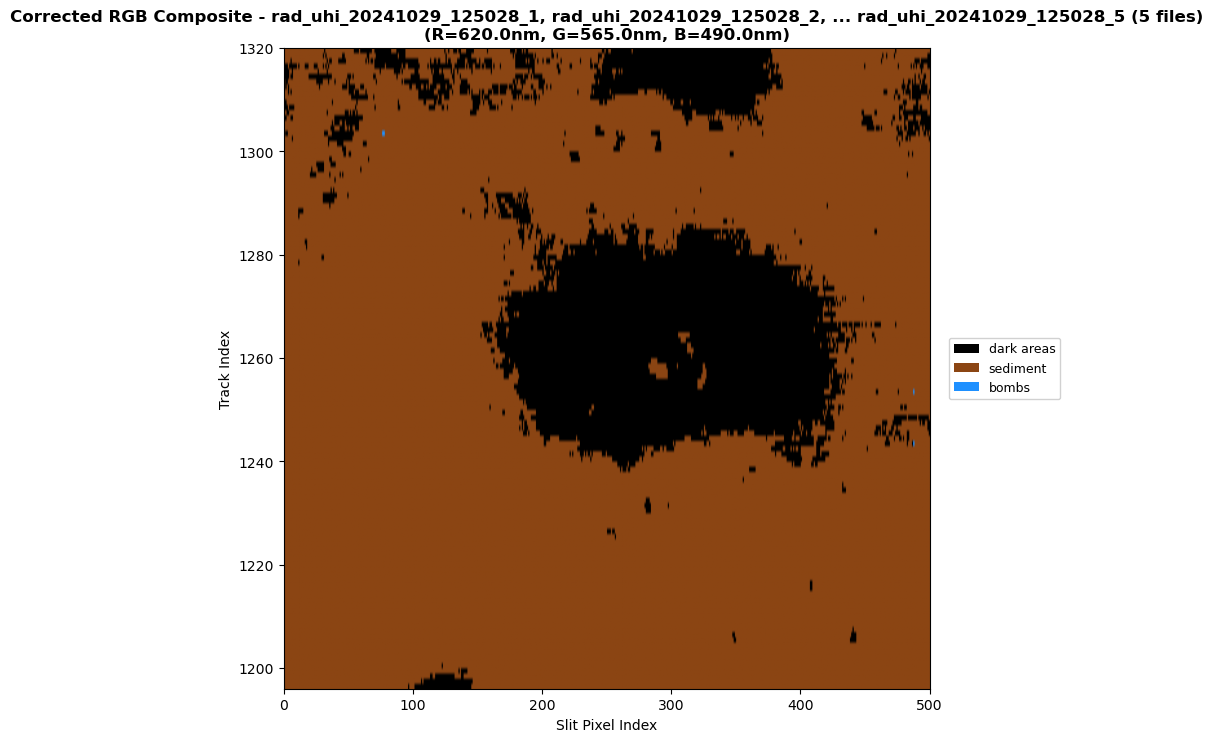


📍 Crop 2 (Bomb 3)
   ROIs: ['dark areas', 'sediment']
      dark areas: 5843 pixels
      sediment: 114189 pixels
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5592 → local track 5592, slit 700
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5530:5654], slit [450:950]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[450, 950], y=[5530, 5654]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid


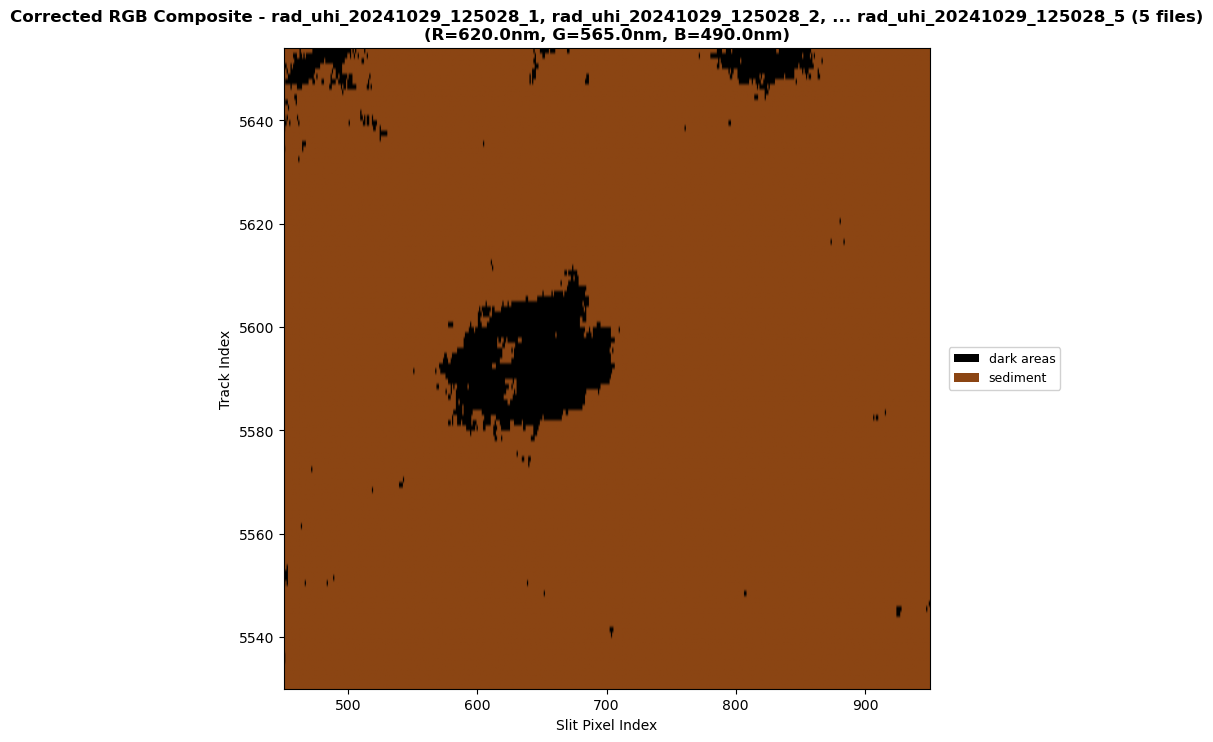


📍 Crop 3 (Bomb 1)
   ROIs: ['dark areas', 'sediment', 'bombs']
      bombs: 7 pixels
      dark areas: 13564 pixels
      sediment: 106461 pixels
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5160 → local track 5160, slit 613
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5098:5222], slit [363:863]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[363, 863], y=[5098, 5222]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid


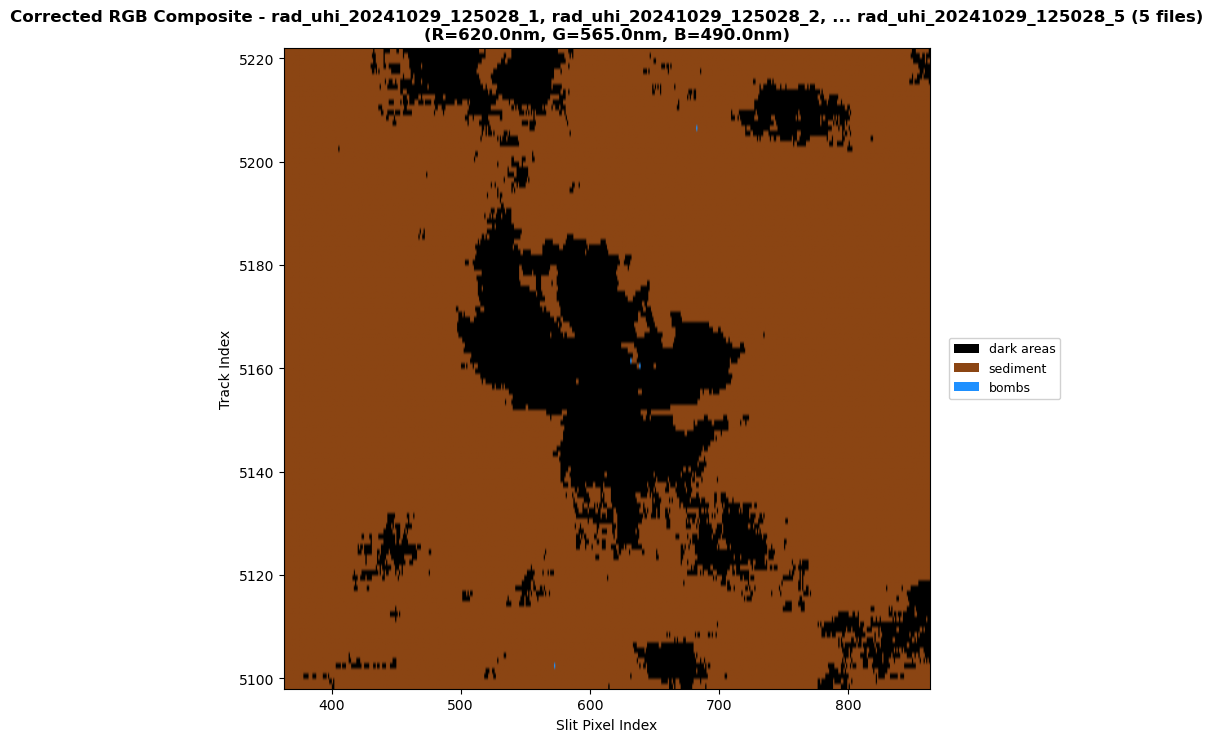


📍 Crop 4 (Dark pits)
   ROIs: ['dark areas', 'sediment', 'bombs']
      bombs: 6 pixels
      dark areas: 1573 pixels
      sediment: 118453 pixels
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 717 → local track 717, slit 385
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [655:779], slit [135:635]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[135, 635], y=[655, 779]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid


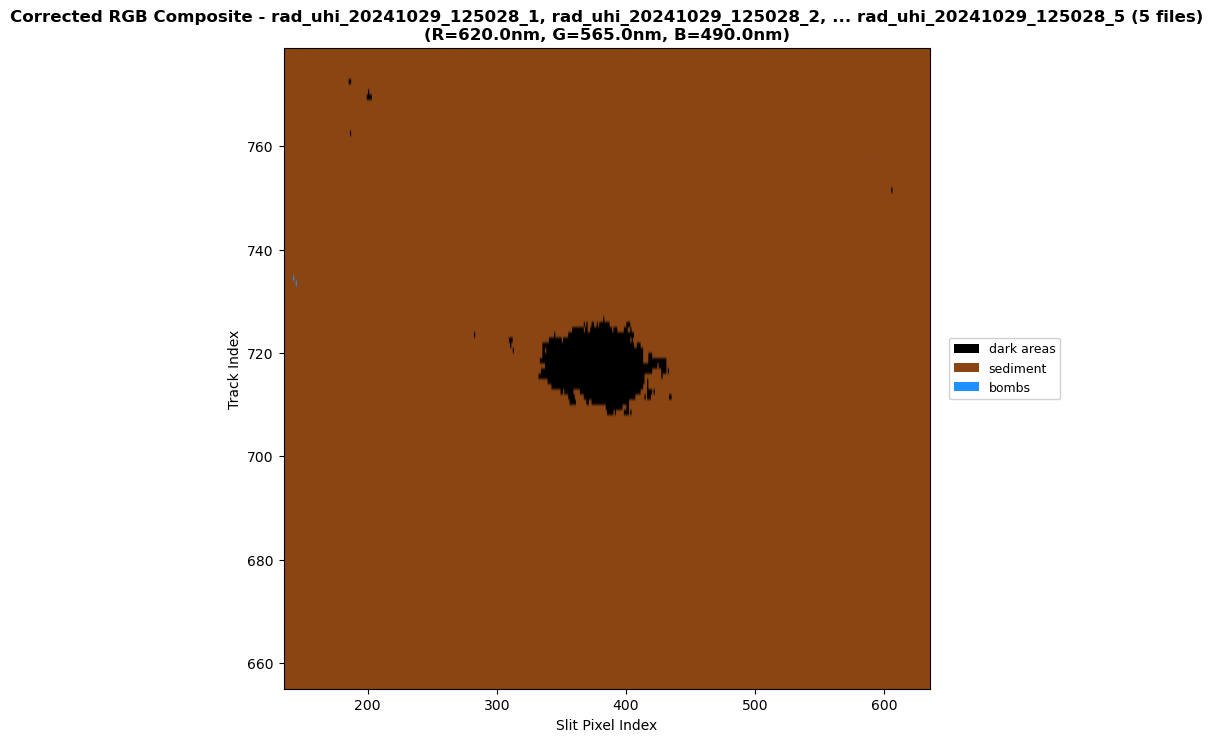

In [11]:
%matplotlib inline

# Plot each crop region separately with plot_rgb (same as dev30)
print("📊 Plotting classification results for each crop region...")

for crop_result in crop_results:
    crop = crop_result["crop"]
    results = crop_result["results"]
    track_min = crop_result["track_min"]

    # Map internal class names to display names
    class_display_names = {
        "classified_bombs": "bombs",
        "classified_dark": "dark areas",
        "classified_sediment": "sediment",
    }

    # Create ROI collection from classification map
    classification_rois = {}
    for class_name in results["class_names"]:
        mask = results["classification_map"] == class_name
        rows, cols = np.where(mask)
        # Convert to global coordinates (add track_min offset)
        pixels = [(col, row + track_min) for row, col in zip(rows, cols)]
        if len(pixels) > 0:
            display_name = class_display_names.get(class_name, class_name)
            classification_rois[display_name] = pixels

    print(f"\n📍 {crop['name']}")
    print(f"   ROIs: {list(classification_rois.keys())}")
    for class_name in sorted(classification_rois.keys()):
        print(f"      {class_name}: {len(classification_rois[class_name])} pixels")

    # Plot with plot_rgb (same visualization as dev30)
    cube.plot_rgb(
        use_corrected=True,
        flip_axes=True,
        flip_horizontal=True,
        figsize=(30, 8.32),
        crop_center_track=crop["track"],
        crop_center_slit=crop["slit"],
        crop_width=crop["width"],
        crop_aspect_ratio=crop["aspect_ratio"],
        display_aspect_ratio=4.0,
        show_file_boundaries=False,
        roi_collection=classification_rois,
        roi_legend_loc="outside",
        roi_marker_size=2,
        roi_legend_markersize=50,
        roi_marker_edgewidth=0,
        roi_overlay_mode="solid",
        roi_solid_pixel_size=1,  
        roi_show_numbers=False,
        roi_legend_show_counts=False,
    )

📊 Plotting and saving classification results for each crop region...
📁 Output directory: e:\mjosa_complete\gref4hsi\mjosa_code\images_for_publication\057_on_028_mosaics

📍 Crop 1 (Bomb 2 - Rust) → crop1_SVM.pdf
   ROIs: ['dark areas', 'sediment', 'bombs']
      bombs: 5 pixels
      dark areas: 18095 pixels
      sediment: 101932 pixels
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 1258 → local track 1258, slit 250
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [1196:1320], slit [0:500]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[0, 500], y=[1196, 1320]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid
   ✅ Saved: e:\mjosa_complete\gref4hsi\mjosa_code\images_for_publication\057_on_028_mosaics\crop1_SVM.pdf


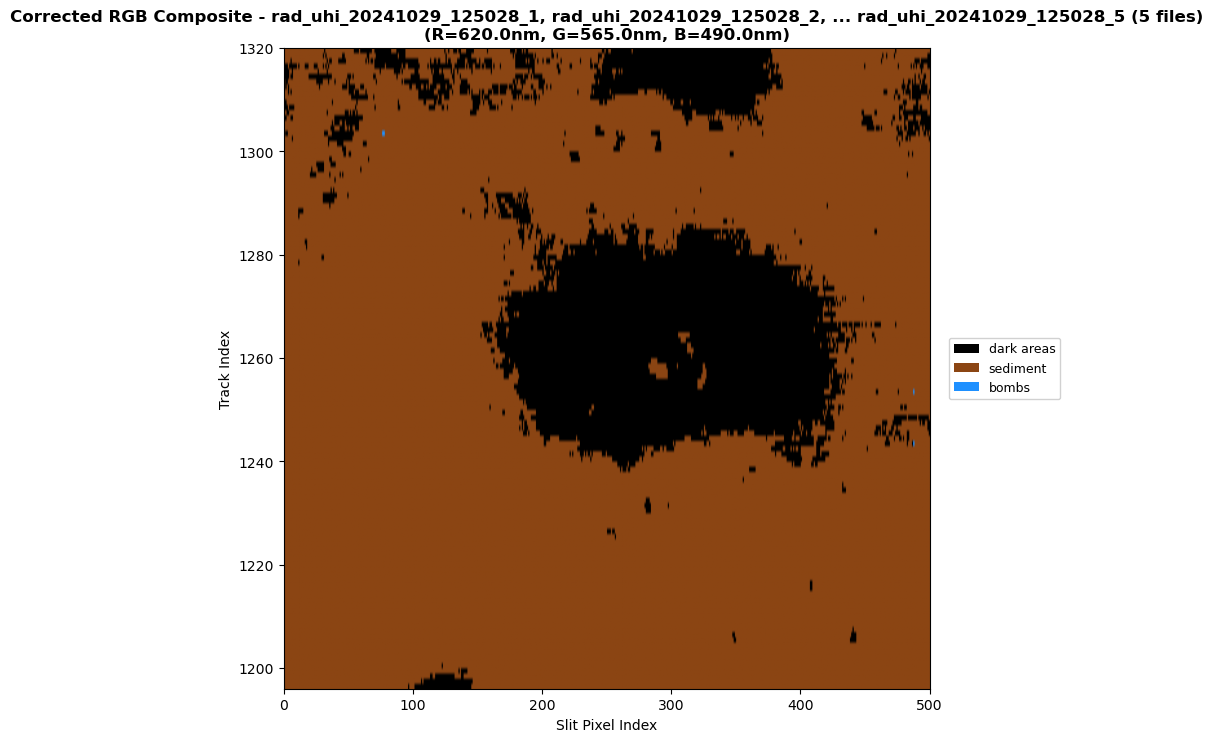


📍 Crop 2 (Bomb 3) → crop2_SVM.pdf
   ROIs: ['dark areas', 'sediment']
      dark areas: 5843 pixels
      sediment: 114189 pixels
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5592 → local track 5592, slit 700
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5530:5654], slit [450:950]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[450, 950], y=[5530, 5654]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid
   ✅ Saved: e:\mjosa_complete\gref4hsi\mjosa_code\images_for_publication\057_on_028_mosaics\crop2_SVM.pdf


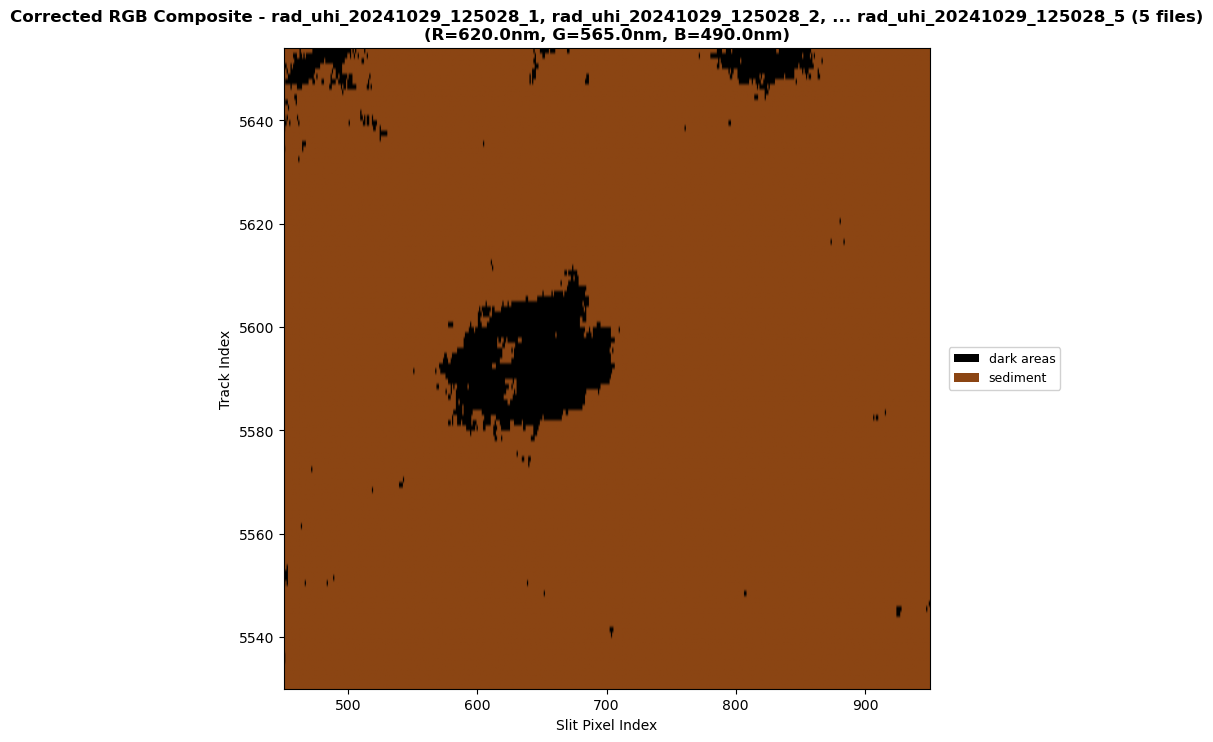


📍 Crop 3 (Bomb 1) → crop3_SVM.pdf
   ROIs: ['dark areas', 'sediment', 'bombs']
      bombs: 7 pixels
      dark areas: 13564 pixels
      sediment: 106461 pixels
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5160 → local track 5160, slit 613
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5098:5222], slit [363:863]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[363, 863], y=[5098, 5222]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid
   ✅ Saved: e:\mjosa_complete\gref4hsi\mjosa_code\images_for_publication\057_on_028_mosaics\crop3_SVM.pdf


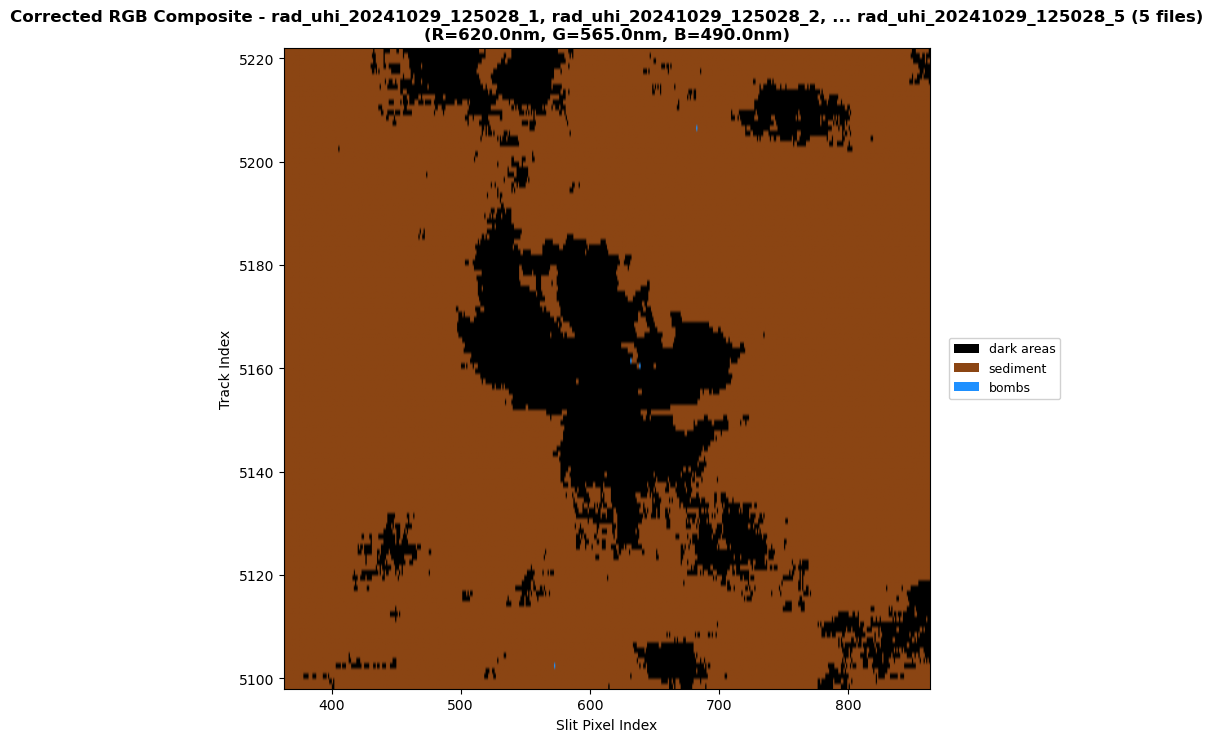


📍 Crop 4 (Dark pits) → crop4_SVM.pdf
   ROIs: ['dark areas', 'sediment', 'bombs']
      bombs: 6 pixels
      dark areas: 1573 pixels
      sediment: 118453 pixels
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 717 → local track 717, slit 385
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [655:779], slit [135:635]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[135, 635], y=[655, 779]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid
   ✅ Saved: e:\mjosa_complete\gref4hsi\mjosa_code\images_for_publication\057_on_028_mosaics\crop4_SVM.pdf


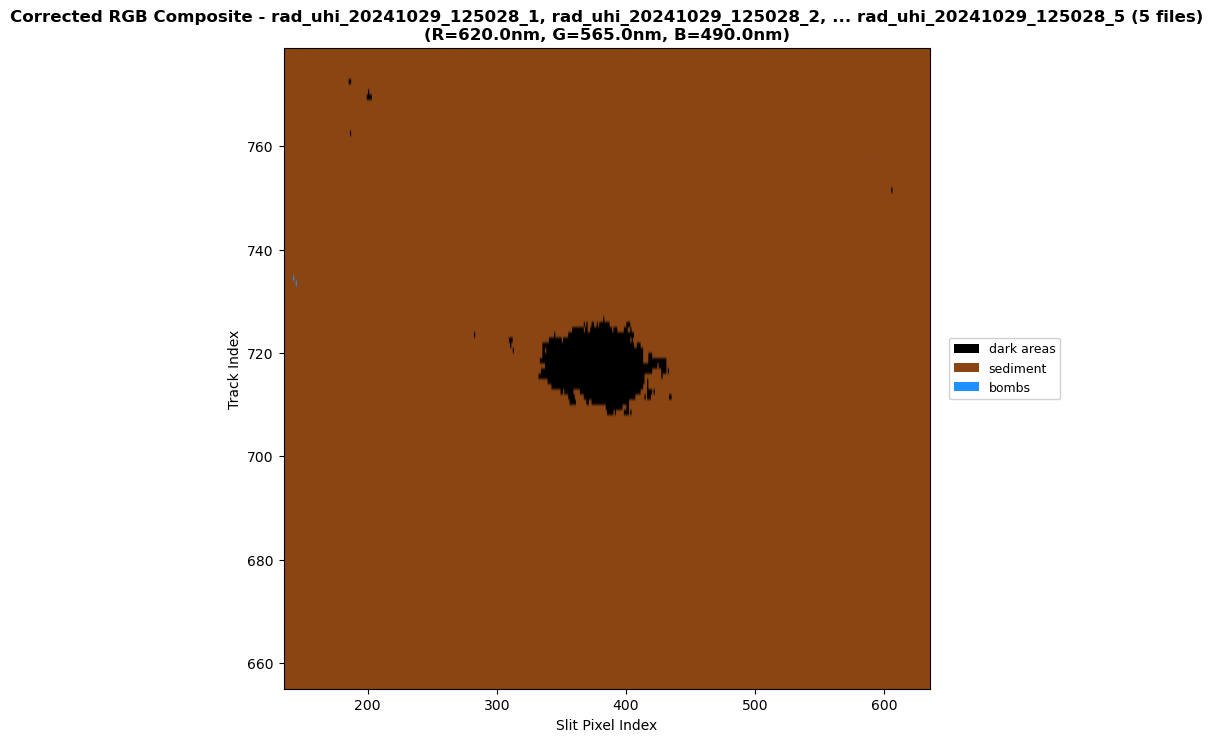


✅ All figures saved!
📁 Location: e:\mjosa_complete\gref4hsi\mjosa_code\images_for_publication\057_on_028_mosaics


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from pathlib import Path

# Create output directory
output_dir = Path.cwd().parent / "images_for_publication" / "057_on_028_mosaics"
output_dir.mkdir(parents=True, exist_ok=True)

print("📊 Plotting and saving classification results for each crop region...")
print(f"📁 Output directory: {output_dir}\n")

for crop_result in crop_results:
    crop = crop_result["crop"]
    results = crop_result["results"]
    track_min = crop_result["track_min"]

    # Create label from crop name (e.g., "Crop 1 (Bomb 2 - Rust)" -> "crop1")
    crop_label = crop["name"].split("(")[0].strip().lower().replace(" ", "")
    
    # Map internal class names to display names
    class_display_names = {
        "classified_bombs": "bombs",
        "classified_dark": "dark areas",
        "classified_sediment": "sediment",
    }

    # Create ROI collection from classification map
    classification_rois = {}
    for class_name in results["class_names"]:
        mask = results["classification_map"] == class_name
        rows, cols = np.where(mask)
        pixels = [(col, row + track_min) for row, col in zip(rows, cols)]
        if len(pixels) > 0:
            display_name = class_display_names.get(class_name, class_name)
            classification_rois[display_name] = pixels

    print(f"📍 {crop['name']} → {crop_label}_SVM.pdf")

    # Save path
    save_path = output_dir / f"{crop_label}_SVM.pdf"
    
    # Monkeypatch plt.show() to clean up before display and save
    _original_show = plt.show
    
    def _cleanup_then_show(*args, **kwargs):
        fig = plt.gcf()
        ax = fig.axes[0]  # Get main image axes
        ax.axis("off")  # Remove axes, ticks, labels

        # Remove legend if present
        legend = ax.get_legend()
        if legend:
            legend.remove()

        # Remove colorbar/other axes
        if len(fig.axes) > 1:
            for a in fig.axes[1:]:
                a.remove()

        ax.set_title("")
        fig.suptitle("")

        # Remove all margins and whitespace
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)

        # Save to file
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
        print(f"   ✅ Saved: {save_path}")

        _original_show(*args, **kwargs)
    
    plt.show = _cleanup_then_show
    
    try:
        cube.plot_rgb(
            use_corrected=True,
            flip_axes=True,
            flip_horizontal=True,
            figsize=(30, 8.32),
            crop_center_track=crop["track"],
            crop_center_slit=crop["slit"],
            crop_width=crop["width"],
            crop_aspect_ratio=crop["aspect_ratio"],
            display_aspect_ratio=4.0,
            show_file_boundaries=False,
            roi_collection=classification_rois,
            roi_legend_loc="outside",
            roi_marker_size=2,
            roi_legend_markersize=50,
            roi_marker_edgewidth=0,
            roi_overlay_mode="solid",
            roi_solid_pixel_size=1,  
            roi_show_numbers=False,
            roi_legend_show_counts=False,
        )
    finally:
        plt.show = _original_show
    
    print()

print("✅ All figures saved!")
print(f"📁 Location: {output_dir}")

## Summary

**What we did:**
1. ✅ Loaded SVM model trained on 057 transect (dev20, 3 classes)
2. ✅ Applied same preprocessing to 028 transect
3. ✅ Defined 4 crop regions (same as dev30)
4. ✅ Classified each crop region separately using 057's model
5. ✅ Visualized each crop with plot_rgb

**Key insight**: Testing if the 057-trained model (3 classes) generalizes to 028 crop regions!

📊 Plotting classification as IMAGES (not ROI markers)...

📍 Crop 1 (Bomb 2 - Rust)
   Classes: ['classified_dark', 'classified_sediment', 'classified_bombs']
   Original shape: (124, 968)
   Cropped to slit [0:500]: (124, 500)
   Pixel counts:
      classified_dark: 12569 pixels (20.3%)
      classified_sediment: 49427 pixels (79.7%)
      classified_bombs: 4 pixels (0.0%)


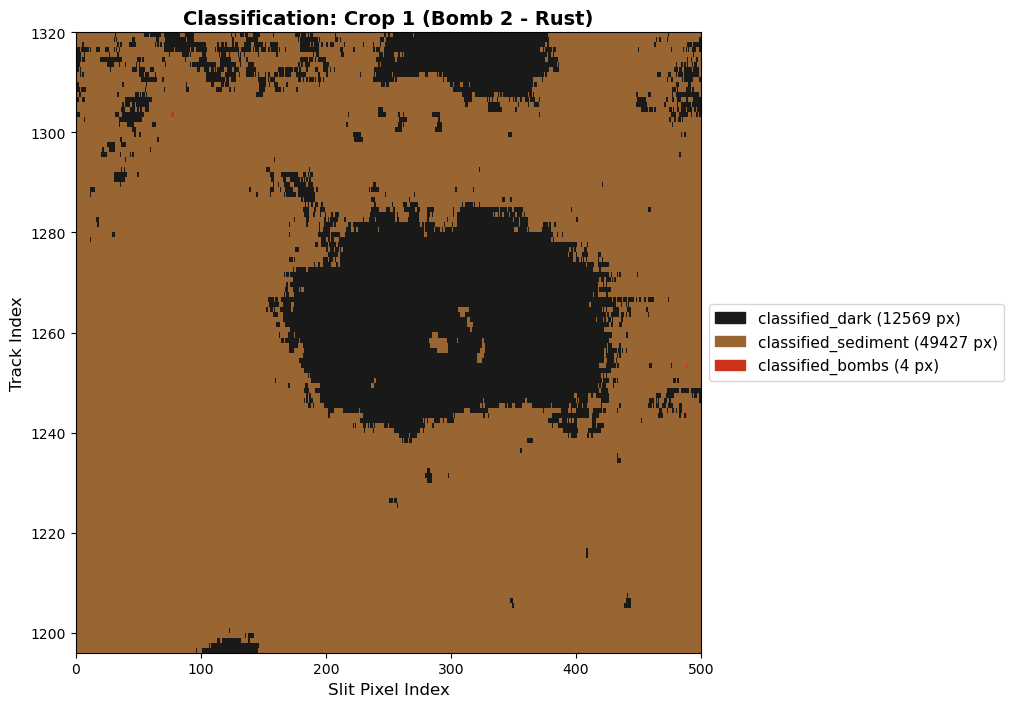


📍 Crop 2 (Bomb 3)
   Classes: ['classified_dark', 'classified_sediment', 'classified_bombs']
   Original shape: (124, 968)
   Cropped to slit [450:950]: (124, 500)
   Pixel counts:
      classified_dark: 3327 pixels (5.4%)
      classified_sediment: 58673 pixels (94.6%)
      classified_bombs: 0 pixels (0.0%)


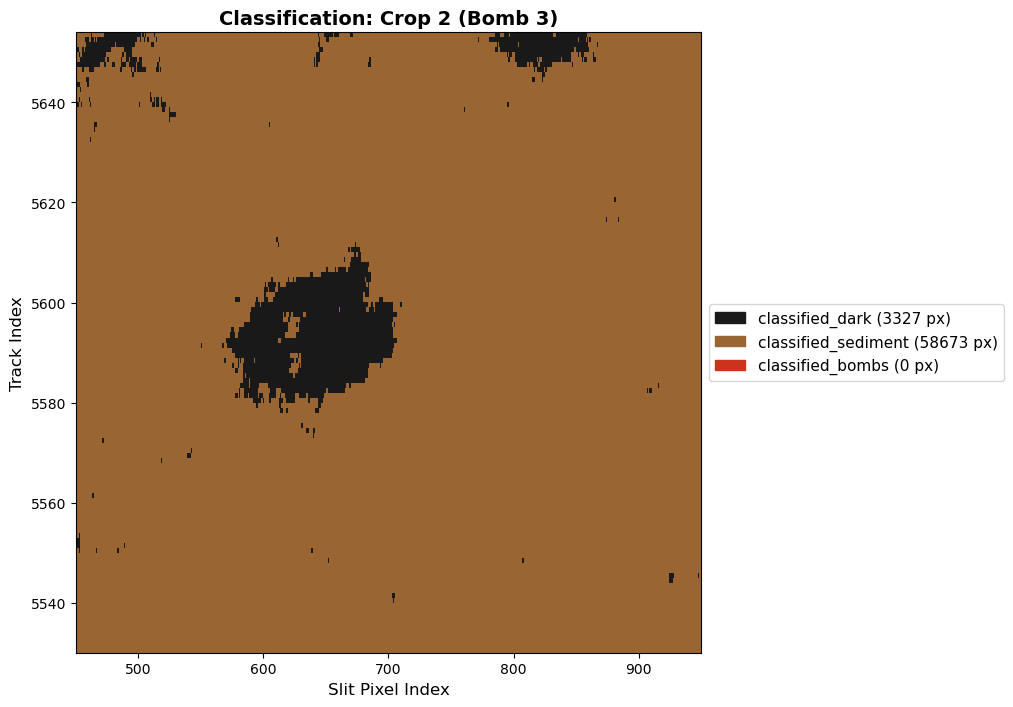


📍 Crop 3 (Bomb 1)
   Classes: ['classified_dark', 'classified_sediment', 'classified_bombs']
   Original shape: (124, 968)
   Cropped to slit [363:863]: (124, 500)
   Pixel counts:
      classified_dark: 11485 pixels (18.5%)
      classified_sediment: 50511 pixels (81.5%)
      classified_bombs: 4 pixels (0.0%)


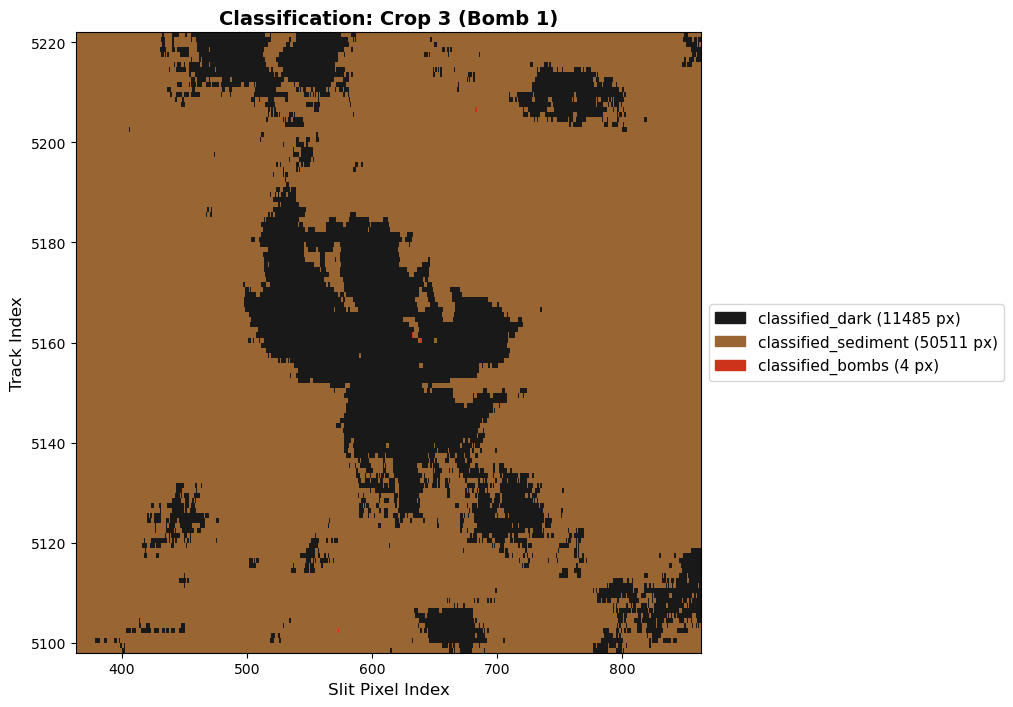


📍 Crop 4 (Dark pits)
   Classes: ['classified_dark', 'classified_sediment', 'classified_bombs']
   Original shape: (124, 968)
   Cropped to slit [135:635]: (124, 500)
   Pixel counts:
      classified_dark: 1097 pixels (1.8%)
      classified_sediment: 60901 pixels (98.2%)
      classified_bombs: 2 pixels (0.0%)


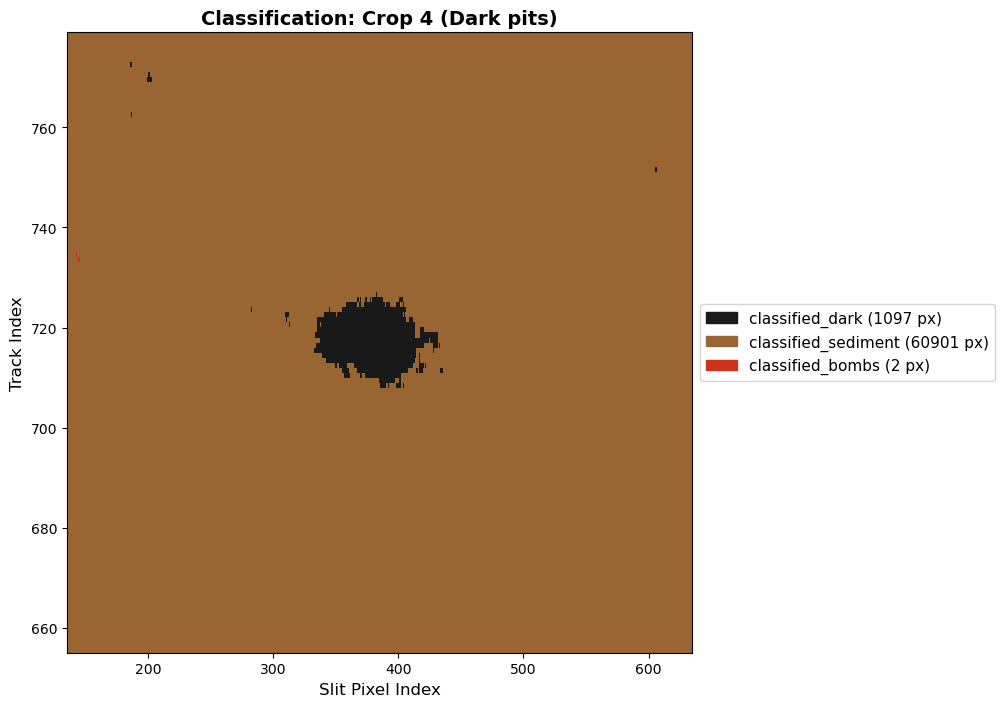

In [12]:
%matplotlib inline

def plot_classification_as_image(
    cube,
    crop,
    classification_map,
    class_names,
    figsize=(30, 8.32),
    flip_axes=True,
    flip_horizontal=True,
):
    """
    Plot classification results as a proper classified image (not ROI markers).
    Each pixel gets the color of its class - like a normal image.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    # Define colors for each class - FIXED to match actual class names from classify_segment
    class_colors = {
        # Dev33 classes (from classify_segment output - prefixed with "classified_")
        "classified_dark": [0.1, 0.1, 0.1],  # Dark gray/black
        "classified_sediment": [0.6, 0.4, 0.2],  # Brown
        "classified_bombs": [0.8, 0.2, 0.1],  # Red-orange
        "classified_unknown": [0.5, 0.5, 0.5],  # Medium gray
        # Original training names (just in case)
        "training_dark": [0.1, 0.1, 0.1],  # Dark gray/black
        "training_sediment": [0.6, 0.4, 0.2],  # Brown
        "training_bombs": [0.8, 0.2, 0.1],  # Red-orange
        # Dev30 classes
        "sediment": [0.6, 0.4, 0.2],  # Brown
        "rust": [0.8, 0.2, 0.1],  # Red-orange
        "dark_bomb": [0.1, 0.1, 0.1],  # Dark gray/black
        "dark_pit": [0.2, 0.2, 0.2],  # Gray
        "halo": [0.9, 0.9, 0.5],  # Yellow
        "uncertain": [0.5, 0.5, 0.5],  # Medium gray
    }

    # Create RGB image from classification map
    height, width = classification_map.shape
    rgb_image = np.zeros((height, width, 3))

    for class_name in class_names:
        mask = classification_map == class_name
        color = class_colors.get(class_name, [0.5, 0.5, 0.5])  # Default gray
        rgb_image[mask] = color

    # Apply flipping to match plot_rgb behavior
    # Step 1: Transpose to match plot_rgb's initial .T.copy()
    rgb_image = rgb_image.transpose(1, 0, 2)  # (slits, tracks, 3)

    # Step 2: Apply flip_axes (like plot_rgb does)
    if flip_axes:
        rgb_image = rgb_image.transpose(1, 0, 2)  # Back to (tracks, slits, 3)

    # Step 3: Apply flip_horizontal (like plot_rgb does)
    if flip_horizontal:
        rgb_image = np.flip(rgb_image, axis=1)  # Flip along axis 1

    # Calculate extent in global coordinates
    half_width_slit = crop["width"] // 2
    half_width_track = int(crop["width"] / crop["aspect_ratio"] / 2)

    slit_min = crop["slit"] - half_width_slit
    slit_max = crop["slit"] + half_width_slit
    track_min = crop["track"] - half_width_track
    track_max = crop["track"] + half_width_track

    if flip_axes:
        # When axes flipped: x=slit, y=track (matches plot_rgb)
        extent = [slit_min, slit_max, track_min, track_max]
        xlabel, ylabel = "Slit Pixel Index", "Track Index"
    else:
        # Normal: x=track, y=slit
        extent = [track_min, track_max, slit_min, slit_max]
        xlabel, ylabel = "Track Index", "Slit Pixel Index"

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Display the classified image
    im = ax.imshow(
        rgb_image,
        extent=extent,
        origin="lower",
        aspect=crop.get("display_aspect_ratio", 4.0),
        interpolation="nearest",
    )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"Classification: {crop['name']}", fontsize=14, fontweight="bold")

    # Create legend with class colors
    legend_patches = []
    for class_name in class_names:
        count = np.sum(classification_map == class_name)
        color = class_colors.get(class_name, [0.5, 0.5, 0.5])
        label = f"{class_name} ({count} px)"
        legend_patches.append(mpatches.Patch(color=color, label=label))

    ax.legend(
        handles=legend_patches,
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        frameon=True,
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()

    return fig, ax


# Plot classification results as proper images (not ROI markers)
print("📊 Plotting classification as IMAGES (not ROI markers)...")

for crop_result in crop_results:  # FIXED: Use crop_results instead of multiclass_crop_results
    crop = crop_result["crop"]
    results = crop_result["results"]

    print(f"\n📍 {crop['name']}")
    print(f"   Classes: {results['class_names']}")

    # CRITICAL FIX: Crop the classification_map to the slit range!
    # classify_segment only crops track dimension, not slit dimension
    half_width_slit = crop["width"] // 2
    crop_slit_min = max(0, crop["slit"] - half_width_slit)
    crop_slit_max = min(
        results["classification_map"].shape[1], crop["slit"] + half_width_slit
    )

    # Crop the classification map to the slit range
    cropped_classification_map = results["classification_map"][
        :, crop_slit_min:crop_slit_max
    ]

    print(f"   Original shape: {results['classification_map'].shape}")
    print(
        f"   Cropped to slit [{crop_slit_min}:{crop_slit_max}]: {cropped_classification_map.shape}"
    )
    print(f"   Pixel counts:")
    for class_name in results["class_names"]:
        count = np.sum(cropped_classification_map == class_name)
        percentage = 100.0 * count / cropped_classification_map.size
        print(f"      {class_name}: {count} pixels ({percentage:.1f}%)")

    # Plot as proper classified image with CROPPED data
    plot_classification_as_image(
        cube,
        crop,
        cropped_classification_map,  # Use CROPPED classification map!
        results["class_names"],
        figsize=(30, 7.18),
        flip_axes=True,
        flip_horizontal=True,
        
    )

---

## 📊 COMPREHENSIVE CLASSIFICATION ANALYSIS

Generate detailed metrics, visualizations, and statistics for cross-transect transfer (057 model → 028 data).

📊 CROSS-TRANSECT TRANSFER ANALYSIS: 057 MODEL → 028 DATA
Model: SVM trained on transect 057 (3-class)
Application: Applied to transect 028 crop regions
Purpose: Test if simpler 057 model (3 classes) can generalize to 028 site

⚠️  NOTE: Analyzing the most recent crop classification.
    To analyze all crops, re-run this cell after each crop classification.


CLASSIFICATION ANALYSIS SUMMARY
Total pixels in map: 120,032
Unknown / unclassified (before): 0 pixels (0.00%)

Per-class counts (before filtering):
  classified_dark: 1,573 pixels (1.31%)
  classified_sediment: 118,453 pixels (98.68%)
  classified_bombs: 6 pixels (0.00%)

Cluster statistics (connected components):
  classified_dark: 71 clusters, largest=1066 px, smallest=1 px, mean=22.2 px
  classified_sediment: 7 clusters, largest=118445 px, smallest=1 px, mean=16921.9 px
  classified_bombs: 5 clusters, largest=2 px, smallest=1 px, mean=1.2 px

💾 Saved CSV summary to: ./saved_data/classification_summary_057_to_028_latest_crop.csv

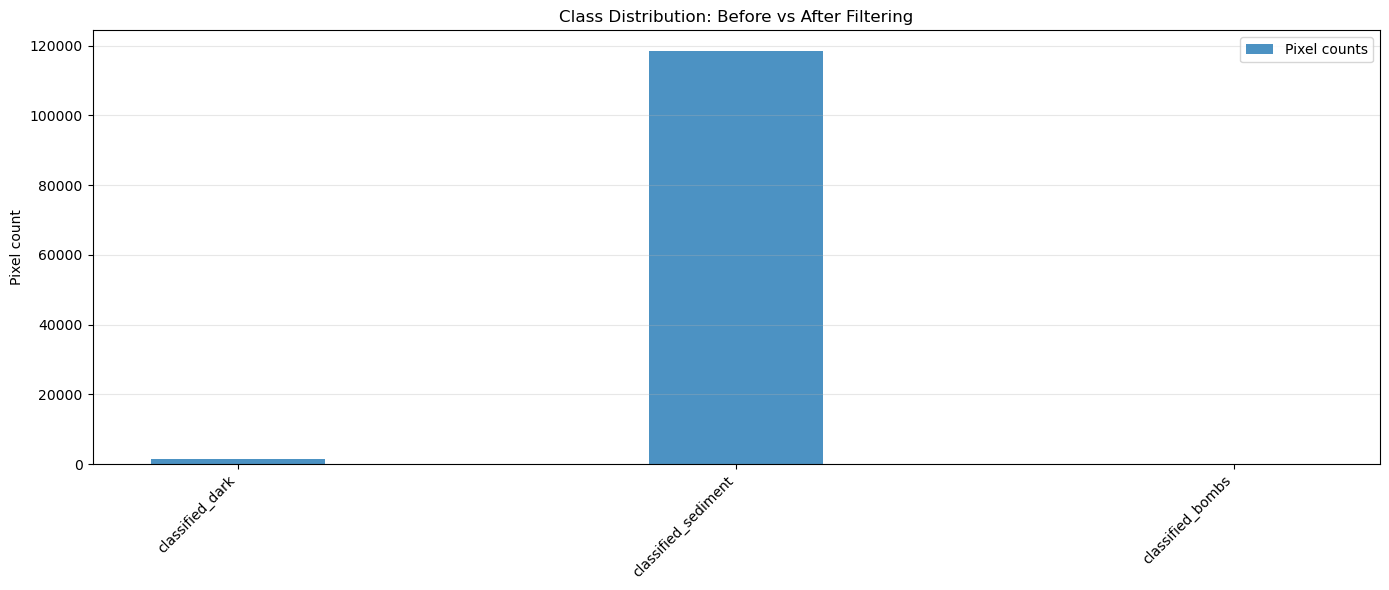

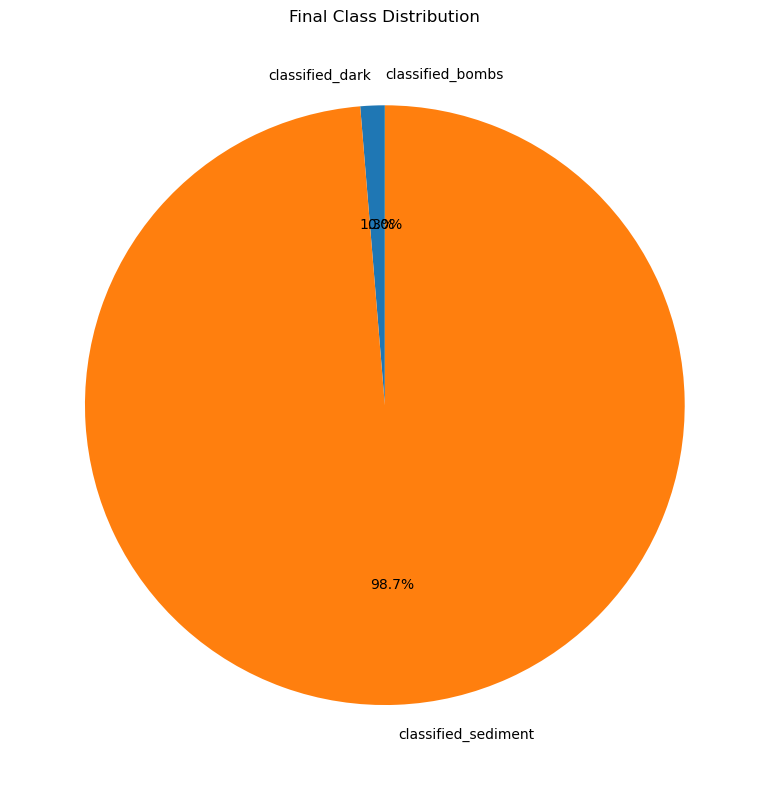

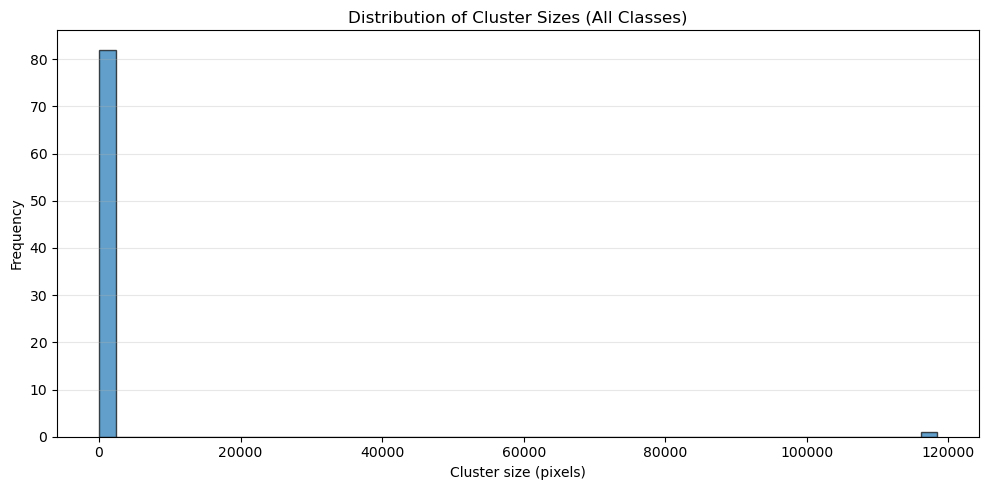


✅ Analysis complete. Returned metrics dictionary.

📝 CROSS-TRANSFER NARRATIVE SUMMARY
The 057 model (trained on 3 classes) was applied to 028 crop regions.
Total pixels in this crop: 120,032

Class distribution in 028 crop when using 057 model:
  • classified_dark: 1,573 pixels (1.31%)
  • classified_sediment: 118,453 pixels (98.68%)
  • classified_bombs: 6 pixels (0.00%)

🔍 KEY INSIGHT:
   The 057 model uses 3 classes (dark, sediment, bombs) while 028 has 5.
   Compare with notebook 9 (028 model on 028 data) to see if the
   simpler 3-class model captures the main seafloor features.


In [13]:
# Import the comprehensive analysis function
from utils.uhi.classification_analysis import analyze_classification_results

print("=" * 80)
print("📊 CROSS-TRANSECT TRANSFER ANALYSIS: 057 MODEL → 028 DATA")
print("=" * 80)
print(f"Model: SVM trained on transect 057 (3-class)")
print(f"Application: Applied to transect 028 crop regions")
print(f"Purpose: Test if simpler 057 model (3 classes) can generalize to 028 site")
print("=" * 80)

# For notebook 11, we have crop-based classification results
# Analyze each crop if available, or the most recent 'results' dict
if "results" in globals() and isinstance(results, dict):
    cls_map = results.get("classification_map", None)
    class_names_var = results.get("class_names", None)

    if cls_map is not None:
        print("\n⚠️  NOTE: Analyzing the most recent crop classification.")
        print(
            "    To analyze all crops, re-run this cell after each crop classification.\n"
        )

        # Run comprehensive analysis
        metrics_057_to_028 = analyze_classification_results(
            classification_map=cls_map,
            filtered_map=None,  # Typically no filtering for crop regions
            class_names=class_names_var,
            track_start=0,
            figsize=(14, 6),
            show_plots=True,
            save_csv="./saved_data/classification_summary_057_to_028_latest_crop.csv",
        )

        print("\n" + "=" * 80)
        print("📝 CROSS-TRANSFER NARRATIVE SUMMARY")
        print("=" * 80)
        print(f"The 057 model (trained on 3 classes) was applied to 028 crop regions.")
        print(f"Total pixels in this crop: {metrics_057_to_028['total_pixels']:,}")
        print(f"\nClass distribution in 028 crop when using 057 model:")

        for cn in class_names_var:
            count = metrics_057_to_028["counts_before"].get(cn, 0)
            pct = 100.0 * count / metrics_057_to_028["total_pixels"]
            print(f"  • {cn}: {count:,} pixels ({pct:.2f}%)")

        print("\n🔍 KEY INSIGHT:")
        print(
            "   The 057 model uses 3 classes (dark, sediment, bombs) while 028 has 5."
        )
        print("   Compare with notebook 9 (028 model on 028 data) to see if the")
        print("   simpler 3-class model captures the main seafloor features.")
        print("=" * 80)
    else:
        print("❌ ERROR: 'results' dict found but no classification_map inside!")
        print("   Please run a crop classification cell first.")
else:
    print("❌ ERROR: 'results' variable not found!")
    print("   Please run the crop classification cells first.")
    print("   This analysis will work on the most recently classified crop.")

---

## 💾 EXPORT COVERAGE STATISTICS

Save classification coverage percentages for each crop region to CSV for cross-notebook comparison.


In [14]:
# Export coverage statistics for notebook 11 (057 model on 028 crops)
import pandas as pd
import os

# Create coverage_stats directory if it doesn't exist
os.makedirs("./coverage_stats", exist_ok=True)

if "crop_results" in globals() and len(crop_results) > 0:
    # Calculate coverage percentages for each crop region
    all_coverage_data = []

    for i, crop_result in enumerate(crop_results):
        crop = crop_result["crop"]
        results = crop_result["results"]
        total_pixels = results["classification_map"].size

        # Calculate crop region bounds for naming
        crop_name = crop["name"]

        for class_name in results["class_names"]:
            count = np.sum(results["classification_map"] == class_name)
            percentage = 100.0 * count / total_pixels
            all_coverage_data.append(
                {
                    "notebook": "11_apply_057_model_to_028",
                    "model": "057_on_028",
                    "region": crop_name,
                    "class": class_name,
                    "pixels": count,
                    "percentage": percentage,
                }
            )

    # Save to CSV
    df_coverage = pd.DataFrame(all_coverage_data)
    output_file = "./coverage_stats/057_on_028_coverage.csv"
    df_coverage.to_csv(output_file, index=False)

    print("✅ Coverage statistics exported!")
    print(f"   File: {output_file}")
    print(f"\n📊 Coverage Summary by Region:")

    # Print summary table grouped by region
    for region in df_coverage["region"].unique():
        print(f"\n{region}:")
        region_data = df_coverage[df_coverage["region"] == region]
        for _, row in region_data.iterrows():
            print(f"  {row['class']:15s}: {row['percentage']:6.2f}%")
else:
    print("❌ ERROR: crop_results not found!")
    print("   Run the crop classification cells first.")

✅ Coverage statistics exported!
   File: ./coverage_stats/057_on_028_coverage.csv

📊 Coverage Summary by Region:

Crop 1 (Bomb 2 - Rust):
  classified_dark:  15.08%
  classified_sediment:  84.92%
  classified_bombs:   0.00%

Crop 2 (Bomb 3):
  classified_dark:   4.87%
  classified_sediment:  95.13%
  classified_bombs:   0.00%

Crop 3 (Bomb 1):
  classified_dark:  11.30%
  classified_sediment:  88.69%
  classified_bombs:   0.01%

Crop 4 (Dark pits):
  classified_dark:   1.31%
  classified_sediment:  98.68%
  classified_bombs:   0.00%
